In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [9]:
df = pd.read_csv('BPL_feature_engineered_v2.csv').drop_duplicates()

In [10]:
df.shape

(1578, 25)

In [11]:
df.head()

,society,colony,property_type,price_outer,price_per_sqft,Total Floors,Facing,Property Age,bedrooms,bathrooms,balconies,area,super_built_up_area,built_up_area,carpet_area,plot_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories
0,sage suncity,bhopal,House,105.0,3750,1.0,NaN,NaN,7,5,0,2800.00,NaN,2800.0,NaN,NaN,0,0,0,0,0,0,1,71,Green View Homes
1,danish hills view,kolar road,Flat,85.0,6508,2.0,North,New Property,3,3,1,1306.08,NaN,NaN,1306.0,NaN,0,0,0,1,0,1,1,35,Green View Homes
2,narmada prem kesar,katara hills,Flat,25.0,2173,3.0,West,New Property,2,2,3,1150.48,1150.0,NaN,850.0,NaN,0,0,0,0,0,0,1,15,Green View Homes
3,gurunanak pura independent house,aishbagh,House,65.0,5909,2.0,West,Old Property,8,5,1,1100.02,NaN,2400.0,2200.0,1100.0,0,0,0,1,0,0,0,18,Road Facing Homes
4,chuna bhatti,chuna bhatti,House,650.0,16250,3.0,NaN,New Property,6,6,2,4000.00,NaN,NaN,NaN,4000.0,1,1,1,1,0,0,2,10,Road Facing Homes


In [12]:
df.columns

Index(['society', 'colony', 'property_type', 'price_outer', 'price_per_sqft',
       'Total Floors', 'Facing', 'Property Age', 'bedrooms', 'bathrooms',
       'balconies', 'area', 'super_built_up_area', 'built_up_area',
       'carpet_area', 'plot_area', 'study room', 'servant room', 'store room',
       'pooja room', 'others', 'view floor plan', 'furnishing_type',
       'luxury_score', 'Overlooking_Categories'],
      dtype='object')

In [13]:
# Numerical columns : price,price_per_sqft,Total Floors,bedrooms,bathrooms,balconies,area,builtuparea,carpetarea,luxury_score.

In [14]:
df.isnull().sum()

society                      4
colony                       0
property_type                0
price_outer                  0
price_per_sqft               0
Total Floors                34
Facing                     702
Property Age               137
bedrooms                     0
bathrooms                    0
balconies                    0
area                         0
super_built_up_area       1225
built_up_area             1128
carpet_area                924
plot_area                  837
study room                   0
servant room                 0
store room                   0
pooja room                   0
others                       0
view floor plan              0
furnishing_type              0
luxury_score                 0
Overlooking_Categories       0
dtype: int64

# price_outer

C:\Users\Yogesh\AppData\Local\Temp\ipykernel_2784\209084645.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_outer'])


<Axes: xlabel='price_outer', ylabel='Density'>

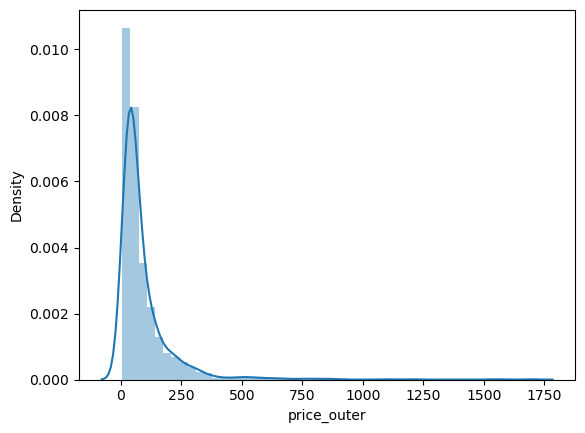

In [15]:
# outliers on the basis of price column
sns.distplot(df['price_outer'])

<Axes: xlabel='price_outer'>

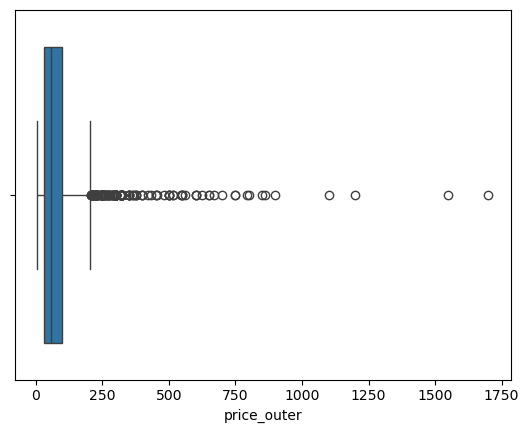

In [16]:
sns.boxplot(x=df['price_outer'])

In [17]:
# Calculate the IQR for the 'price' column
Q1 = df['price_outer'].quantile(0.25)
Q3 = df['price_outer'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['price_outer'] < lower_bound) | (df['price_outer'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers.shape[0]
outliers_price_stats = outliers['price_outer'].describe()

num_outliers, outliers_price_stats

(152,
 count     152.000000
 mean      371.289474
 std       231.285685
 min       207.000000
 25%       240.000000
 50%       295.000000
 75%       400.000000
 max      1700.000000
 Name: price_outer, dtype: float64)

In [18]:
outliers.sort_values('price_outer',ascending=False).head(20)

,society,colony,property_type,price_outer,price_per_sqft,Total Floors,Facing,Property Age,bedrooms,bathrooms,balconies,area,super_built_up_area,built_up_area,carpet_area,plot_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories
968,area colony,arera colony,House,1700.0,40476,2.0,NaN,Old Property,4,4,3,4200.02,NaN,NaN,NaN,4200.0,0,1,1,0,0,0,2,0,Road Facing Homes
1489,10 no stop arera colony,arera colony,House,1550.0,34444,2.0,East,New Property,10,9,2,4500.06,NaN,NaN,NaN,4500.0,1,1,1,1,0,0,2,118,Green View Homes
1132,shymala hills,bhopal,House,1200.0,36363,2.0,East,Old Property,10,4,3,3300.06,NaN,NaN,3300.0,3300.0,0,0,0,0,0,0,1,12,Premium Scenic Homes
894,b sector shahpura,shahpura,House,1100.0,20560,2.0,East,Old Property,5,5,3,5350.19,NaN,4000.0,NaN,5350.0,1,1,1,1,0,0,0,38,Road Facing Homes
1222,arera colony,arera colony,House,900.0,17708,2.0,West,Old Property,1,1,2,5082.45,NaN,NaN,NaN,4000.0,1,1,1,1,0,0,1,27,Green View Homes
441,amrit bindras pebble bay,bagmugaliya,House,860.0,12314,3.0,North,Moderate Property,7,8,2,6983.92,NaN,NaN,NaN,5400.0,0,1,0,1,1,0,2,23,Amenity Facing Homes
718,b sector shahpura,shahpura,House,850.0,21250,3.0,NaN,Old Property,4,4,3,4000.00,NaN,NaN,NaN,4000.0,0,0,0,0,0,0,1,38,Road Facing Homes
474,shri rameshwaram,bagmuliya,House,800.0,7434,2.0,East,Under Construction,6,6,2,10761.37,NaN,NaN,NaN,10760.0,1,1,1,1,0,0,0,85,Amenity Facing Homes
637,amrit bindras pebble bay,bagmugaliya,House,795.0,7388,3.0,North,NaN,6,6,2,10760.69,NaN,NaN,NaN,10760.0,1,1,1,1,0,0,1,46,Green View Homes
769,pebble bay,bagmugaliya,House,750.0,6970,2.0,NaN,NaN,6,6,2,10760.40,NaN,NaN,NaN,10760.0,1,1,1,1,0,0,2,72,Amenity Facing Homes


In [19]:
# genuine outliers

# price_per_sqft

C:\Users\Yogesh\AppData\Local\Temp\ipykernel_2784\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

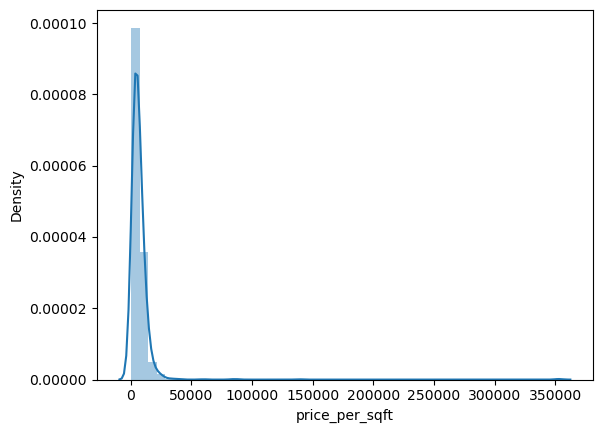

In [20]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

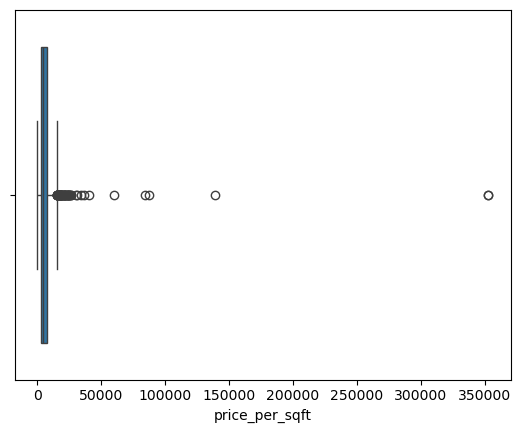

In [21]:
sns.boxplot(x=df['price_per_sqft'])

In [22]:
# Calculate the IQR for the 'price' column
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_sqft = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers_sqft.shape[0]
outliers_sqft_stats = outliers_sqft['price_per_sqft'].describe()

num_outliers, outliers_sqft_stats

(71,
 count        71.000000
 mean      33853.267606
 std       57851.414619
 min       15463.000000
 25%       16666.000000
 50%       19047.000000
 75%       24166.500000
 max      352941.000000
 Name: price_per_sqft, dtype: float64)

In [23]:
outliers_sqft.sort_values(by='price_per_sqft',ascending=False)

,society,colony,property_type,price_outer,price_per_sqft,Total Floors,Facing,Property Age,bedrooms,bathrooms,balconies,area,super_built_up_area,built_up_area,carpet_area,plot_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories
665,fine homes,arera colony,Flat,30.0,352941,0.0,NaN,Old Property,2,2,0,8.50,NaN,NaN,9.0,NaN,0,0,0,0,0,0,1,0,Road Facing Homes
235,aura mall,shahpura,Flat,30.0,352941,0.0,South,Old Property,2,2,0,8.50,NaN,NaN,9.0,NaN,0,0,0,0,0,0,1,0,Road Facing Homes
95,ratibad,neelbad,House,50.0,138888,2.0,NaN,New Property,5,5,0,36.00,NaN,NaN,42.0,36.0,0,0,0,0,0,0,1,8,Road Facing Homes
200,aishbagh,aishbagh,House,28.0,87500,NaN,NaN,Old Property,4,1,0,32.00,NaN,NaN,NaN,32.0,0,0,0,0,1,0,1,20,Green View Homes
595,kolar road,kolar road,House,105.0,84000,2.0,West,New Property,3,3,3,125.00,NaN,1800.0,NaN,125.0,0,0,0,0,1,0,1,79,Road Facing Homes
664,chola rod,bhopal,House,12.0,60000,1.0,NaN,New Property,2,2,1,20.00,NaN,NaN,NaN,20.0,0,0,0,0,0,0,1,0,Road Facing Homes
968,area colony,arera colony,House,1700.0,40476,2.0,NaN,Old Property,4,4,3,4200.02,NaN,NaN,NaN,4200.0,0,1,1,0,0,0,2,0,Road Facing Homes
1132,shymala hills,bhopal,House,1200.0,36363,2.0,East,Old Property,10,4,3,3300.06,NaN,NaN,3300.0,3300.0,0,0,0,0,0,0,1,12,Premium Scenic Homes
1489,10 no stop arera colony,arera colony,House,1550.0,34444,2.0,East,New Property,10,9,2,4500.06,NaN,NaN,NaN,4500.0,1,1,1,1,0,0,2,118,Green View Homes
818,kohefiza,shahjahanabad,House,700.0,31111,3.0,NaN,Old Property,10,5,2,2250.01,NaN,NaN,NaN,2250.0,0,0,0,0,0,0,1,0,Road Facing Homes


In [24]:
df.head()

,society,colony,property_type,price_outer,price_per_sqft,Total Floors,Facing,Property Age,bedrooms,bathrooms,balconies,area,super_built_up_area,built_up_area,carpet_area,plot_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories
0,sage suncity,bhopal,House,105.0,3750,1.0,NaN,NaN,7,5,0,2800.00,NaN,2800.0,NaN,NaN,0,0,0,0,0,0,1,71,Green View Homes
1,danish hills view,kolar road,Flat,85.0,6508,2.0,North,New Property,3,3,1,1306.08,NaN,NaN,1306.0,NaN,0,0,0,1,0,1,1,35,Green View Homes
2,narmada prem kesar,katara hills,Flat,25.0,2173,3.0,West,New Property,2,2,3,1150.48,1150.0,NaN,850.0,NaN,0,0,0,0,0,0,1,15,Green View Homes
3,gurunanak pura independent house,aishbagh,House,65.0,5909,2.0,West,Old Property,8,5,1,1100.02,NaN,2400.0,2200.0,1100.0,0,0,0,1,0,0,0,18,Road Facing Homes
4,chuna bhatti,chuna bhatti,House,650.0,16250,3.0,NaN,New Property,6,6,2,4000.00,NaN,NaN,NaN,4000.0,1,1,1,1,0,0,2,10,Road Facing Homes


In [25]:
qty = (df['area']/df['price_outer']).quantile(0.003)
idx = df[(df['area']/df['price_outer'])<qty].index
df.drop(idx,inplace=True)

C:\Users\Yogesh\AppData\Local\Temp\ipykernel_2784\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

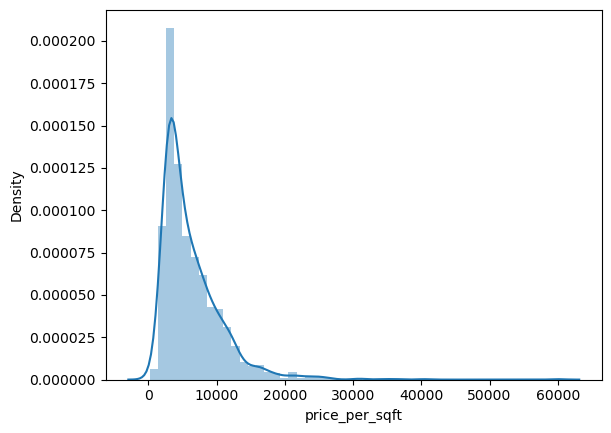

In [26]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

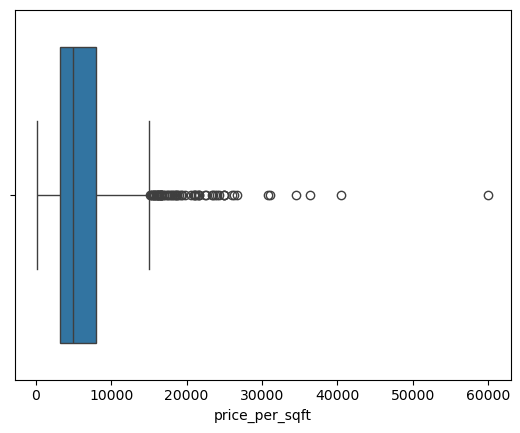

In [27]:
sns.boxplot(x=df['price_per_sqft'])

In [28]:
df['price_per_sqft'].describe()

count     1573.000000
mean      6307.598856
std       4568.407053
min        223.000000
25%       3250.000000
50%       4900.000000
75%       8003.000000
max      60000.000000
Name: price_per_sqft, dtype: float64

In [29]:
# Calculate the IQR for the 'price' column
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_sqft = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers_sqft.shape[0]
outliers_sqft_stats = outliers_sqft['price_per_sqft'].describe()

num_outliers, outliers_sqft_stats

(68,
 count       68.000000
 mean     20848.970588
 std       7135.923737
 min      15151.000000
 25%      16590.250000
 50%      18485.500000
 75%      22755.500000
 max      60000.000000
 Name: price_per_sqft, dtype: float64)

In [30]:
outliers_sqft

,society,colony,property_type,price_outer,price_per_sqft,Total Floors,Facing,Property Age,bedrooms,bathrooms,balconies,area,super_built_up_area,built_up_area,carpet_area,plot_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories
4,chuna bhatti,chuna bhatti,House,650.0,16250,3.0,NaN,New Property,6,6,2,4000.00,NaN,NaN,NaN,4000.0,1,1,1,1,0,0,2,10,Road Facing Homes
20,naveen nagar,bhopal,House,180.0,18750,2.0,North,Old Property,4,4,1,960.00,NaN,NaN,NaN,960.0,0,0,0,0,0,0,0,3,Road Facing Homes
22,hoshangabad road,hoshangabad road,House,260.0,18571,4.0,NaN,NaN,4,5,1,1400.03,NaN,NaN,NaN,1400.0,0,1,0,1,1,0,1,22,Amenity Facing Homes
28,gulmohar g3,shahpura,House,600.0,30769,1.0,North-East,Old Property,4,4,1,1950.01,NaN,NaN,NaN,1950.0,0,0,0,0,0,0,0,9,Green View Homes
88,amrit south avenue,shahpura,House,300.0,16666,2.0,South-West,Old Property,3,3,1,1800.07,NaN,3000.0,NaN,1800.0,0,0,0,0,0,0,1,0,Road Facing Homes
90,narela jod ayodhya bypass,ayodhya bypass,House,315.0,21000,3.0,East,Moderate Property,2,2,2,1500.00,NaN,NaN,NaN,1500.0,0,1,0,0,1,0,1,4,Green View Homes
143,hoshangabad road,hoshangabad road,House,250.0,22563,2.0,NaN,New Property,4,4,0,1108.01,NaN,NaN,NaN,1108.0,0,0,0,0,0,0,1,22,Amenity Facing Homes
144,sector c indrapuri,piplani,House,450.0,16304,2.0,NaN,Old Property,8,5,3,2760.06,NaN,NaN,NaN,2760.0,0,0,0,0,0,0,1,0,Road Facing Homes
161,panchvati market,bhopal,House,235.0,15666,2.0,East,Old Property,4,3,1,1500.06,NaN,NaN,NaN,1500.0,0,0,0,0,0,0,1,8,Road Facing Homes
213,priyadarshini the athenaeum,bawadia kalan,House,515.0,17758,4.0,East,New Property,6,7,3,2900.10,NaN,7000.0,NaN,2900.0,0,0,0,0,0,0,1,23,Road Facing Homes


In [31]:
nty_data = outliers_sqft['price_per_sqft'].quantile(0.99)

In [32]:
outliers_sqft[outliers_sqft['price_per_sqft']>nty_data]

,society,colony,property_type,price_outer,price_per_sqft,Total Floors,Facing,Property Age,bedrooms,bathrooms,balconies,area,super_built_up_area,built_up_area,carpet_area,plot_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories
664,chola rod,bhopal,House,12.0,60000,1.0,NaN,New Property,2,2,1,20.0,NaN,NaN,NaN,20.0,0,0,0,0,0,0,1,0,Road Facing Homes


In [33]:
idx = outliers_sqft[outliers_sqft['price_per_sqft']>nty_data].index
df.drop(idx,inplace=True)

In [34]:
df.head()

,society,colony,property_type,price_outer,price_per_sqft,Total Floors,Facing,Property Age,bedrooms,bathrooms,balconies,area,super_built_up_area,built_up_area,carpet_area,plot_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories
0,sage suncity,bhopal,House,105.0,3750,1.0,NaN,NaN,7,5,0,2800.00,NaN,2800.0,NaN,NaN,0,0,0,0,0,0,1,71,Green View Homes
1,danish hills view,kolar road,Flat,85.0,6508,2.0,North,New Property,3,3,1,1306.08,NaN,NaN,1306.0,NaN,0,0,0,1,0,1,1,35,Green View Homes
2,narmada prem kesar,katara hills,Flat,25.0,2173,3.0,West,New Property,2,2,3,1150.48,1150.0,NaN,850.0,NaN,0,0,0,0,0,0,1,15,Green View Homes
3,gurunanak pura independent house,aishbagh,House,65.0,5909,2.0,West,Old Property,8,5,1,1100.02,NaN,2400.0,2200.0,1100.0,0,0,0,1,0,0,0,18,Road Facing Homes
4,chuna bhatti,chuna bhatti,House,650.0,16250,3.0,NaN,New Property,6,6,2,4000.00,NaN,NaN,NaN,4000.0,1,1,1,1,0,0,2,10,Road Facing Homes


# Total Floors

In [35]:
df['Total Floors'].describe()

count    1539.000000
mean        2.541910
std         1.881407
min         0.000000
25%         2.000000
50%         2.000000
75%         3.000000
max        33.000000
Name: Total Floors, dtype: float64

In [36]:

# Calculate the IQR for the 'price' column
Q1 = df['Total Floors'].quantile(0.25)
Q3 = df['Total Floors'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_totalfloors = df[(df['Total Floors'] < lower_bound) | (df['Total Floors'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers_totalfloors.shape[0]
outliers_totalfloors_stats = outliers_totalfloors['Total Floors'].describe()

num_outliers, outliers_totalfloors_stats

(264,
 count    264.000000
 mean       4.583333
 std        3.463095
 min        0.000000
 25%        0.000000
 50%        5.000000
 75%        6.000000
 max       33.000000
 Name: Total Floors, dtype: float64)

In [37]:
lower_bound , upper_bound

(0.5, 4.5)

In [38]:
outliers_totalfloors.sort_values(by='Total Floors',ascending=False)

,society,colony,property_type,price_outer,price_per_sqft,Total Floors,Facing,Property Age,bedrooms,bathrooms,balconies,area,super_built_up_area,built_up_area,carpet_area,plot_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories
1067,tata amantra,bhopal,Flat,95.00,5937,33.0,NaN,New Property,3,2,1,1600.13,1600.0,NaN,NaN,NaN,0,0,0,0,0,0,1,0,Road Facing Homes
605,mirchandani shalimar fortleza,hoshangabad road,House,115.00,6388,17.0,NaN,New Property,3,3,1,1800.25,NaN,NaN,NaN,1800.0,0,0,0,0,1,0,0,13,Premium Scenic Homes
840,gammon shrishti cbd,central bhopal,Flat,250.00,11532,15.0,North,New Property,3,3,2,2167.88,2081.0,NaN,NaN,NaN,1,1,0,1,1,0,1,85,Premium Scenic Homes
1253,gammon shrishti cbd,central bhopal,Flat,240.00,11532,13.0,East,New Property,3,4,3,2081.17,2081.0,NaN,1246.0,NaN,0,1,0,0,0,1,1,80,Amenity Facing Homes
538,paras emperor phase 1,bawadia kalan,Flat,165.00,12692,11.0,NaN,New Property,3,3,2,1300.03,1890.0,NaN,1300.0,NaN,0,0,0,0,0,0,1,38,Amenity Facing Homes
1453,gammon shrishti cbd,central bhopal,Flat,250.00,12013,10.0,East,New Property,3,4,3,2081.08,2081.0,NaN,1246.0,NaN,0,1,0,0,0,0,1,69,Amenity Facing Homes
197,covered campus society,hoshangabad road,Flat,115.00,6571,10.0,East,New Property,3,3,2,1750.11,1750.0,NaN,1150.0,NaN,0,0,0,0,1,0,0,35,Premium Scenic Homes
1271,sheetal paradise,ayodhya bypass,Flat,44.90,2806,10.0,East,Moderate Property,2,3,2,1600.14,1600.0,1300.0,1100.0,NaN,0,0,0,1,0,0,2,28,Road Facing Homes
545,mahalaxmi awasiya parisar,bhopal,Flat,65.00,5909,10.0,North,New Property,3,3,2,1100.02,1350.0,NaN,1100.0,NaN,0,0,0,0,0,0,1,28,Green View Homes
1419,mirchandani shalimar fortleza,hoshangabad road,Flat,110.00,10566,9.0,East,New Property,3,3,3,1041.08,1800.0,NaN,1041.0,NaN,0,0,0,0,0,0,0,58,Premium Scenic Homes


In [39]:
df.head()

,society,colony,property_type,price_outer,price_per_sqft,Total Floors,Facing,Property Age,bedrooms,bathrooms,balconies,area,super_built_up_area,built_up_area,carpet_area,plot_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories
0,sage suncity,bhopal,House,105.0,3750,1.0,NaN,NaN,7,5,0,2800.00,NaN,2800.0,NaN,NaN,0,0,0,0,0,0,1,71,Green View Homes
1,danish hills view,kolar road,Flat,85.0,6508,2.0,North,New Property,3,3,1,1306.08,NaN,NaN,1306.0,NaN,0,0,0,1,0,1,1,35,Green View Homes
2,narmada prem kesar,katara hills,Flat,25.0,2173,3.0,West,New Property,2,2,3,1150.48,1150.0,NaN,850.0,NaN,0,0,0,0,0,0,1,15,Green View Homes
3,gurunanak pura independent house,aishbagh,House,65.0,5909,2.0,West,Old Property,8,5,1,1100.02,NaN,2400.0,2200.0,1100.0,0,0,0,1,0,0,0,18,Road Facing Homes
4,chuna bhatti,chuna bhatti,House,650.0,16250,3.0,NaN,New Property,6,6,2,4000.00,NaN,NaN,NaN,4000.0,1,1,1,1,0,0,2,10,Road Facing Homes


In [40]:
df.shape

(1572, 25)

# area

C:\Users\Yogesh\AppData\Local\Temp\ipykernel_2784\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

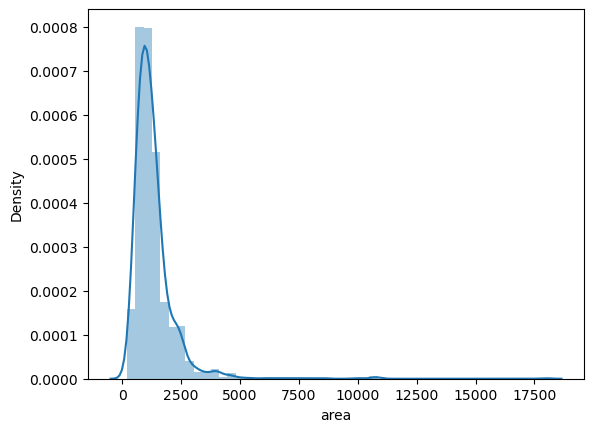

In [41]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

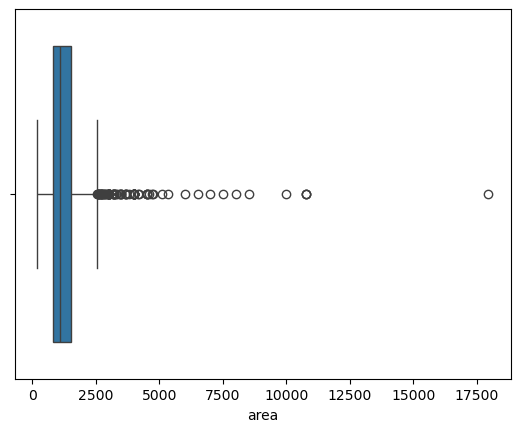

In [42]:
sns.boxplot(x=df['area'])

In [43]:
df['area'].describe()

count     1572.000000
mean      1316.828486
std       1002.731590
min        194.040000
25%        800.000000
50%       1100.085000
75%       1500.060000
max      17955.800000
Name: area, dtype: float64

In [44]:
# Calculate the IQR for the 'price' column
Q1 = df['area'].quantile(0.25)
Q3 = df['area'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_area = df[(df['area'] < lower_bound) | (df['area'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers_area.shape[0]
outliers_area_stats = outliers_area['area'].describe()

num_outliers, outliers_area_stats

(81,
 count       81.000000
 mean      4250.016543
 std       2466.296751
 min       2550.180000
 25%       2980.180000
 50%       3500.000000
 75%       4200.020000
 max      17955.800000
 Name: area, dtype: float64)

In [45]:
lower_bound,upper_bound

(-250.08999999999992, 2550.1499999999996)

In [46]:
outliers_area

,society,colony,property_type,price_outer,price_per_sqft,Total Floors,Facing,Property Age,bedrooms,bathrooms,balconies,area,super_built_up_area,built_up_area,carpet_area,plot_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories
0,sage suncity,bhopal,House,105.0,3750,1.0,NaN,NaN,7,5,0,2800.00,NaN,2800.0,NaN,NaN,0,0,0,0,0,0,1,71,Green View Homes
4,chuna bhatti,chuna bhatti,House,650.0,16250,3.0,NaN,New Property,6,6,2,4000.00,NaN,NaN,NaN,4000.0,1,1,1,1,0,0,2,10,Road Facing Homes
8,kolar road,kolar road,House,145.0,5370,1.0,NaN,NaN,4,4,1,2700.19,NaN,2700.0,NaN,NaN,0,0,0,0,0,0,1,13,Road Facing Homes
26,bagsewaniya,bagmuliya,House,295.0,10350,2.0,East,New Property,4,4,1,2850.24,NaN,NaN,NaN,2850.0,0,0,0,1,0,0,0,31,Amenity Facing Homes
39,lalita nagar,gehu kheda,House,100.0,3333,1.0,North,New Property,6,6,2,3000.30,NaN,3000.0,NaN,NaN,0,0,0,0,0,0,1,21,Road Facing Homes
40,f-sectorkolar road,kolar road,House,39.0,520,2.0,North,Moderate Property,3,2,1,7500.00,NaN,NaN,NaN,7500.0,0,0,0,0,0,0,1,8,Road Facing Homes
43,signature residency,shirdipuram,Flat,130.0,724,6.0,NaN,Moderate Property,4,3,3,17955.80,NaN,NaN,17954.0,NaN,0,0,0,0,0,0,1,93,Amenity Facing Homes
50,sanjeev nagar,gandhinagar,House,175.0,3696,1.0,West,New Property,7,6,3,4734.85,NaN,4600.0,2400.0,NaN,0,0,0,0,0,0,1,7,Green View Homes
71,khajuri,bhopal,House,69.0,2156,2.0,NaN,New Property,2,2,2,3200.37,NaN,NaN,NaN,3200.0,0,0,0,1,0,0,1,0,Road Facing Homes
82,18 down hills,bawadia kalan,House,550.0,15000,3.0,NaN,Under Construction,5,8,3,3666.67,NaN,NaN,NaN,3200.0,1,1,1,1,0,0,1,22,Road Facing Homes


In [47]:
nty = outliers_area['area'].quantile(0.99)
idx = outliers_area[outliers_area['area']>nty].index
df.drop(idx,inplace=True)

C:\Users\Yogesh\AppData\Local\Temp\ipykernel_2784\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

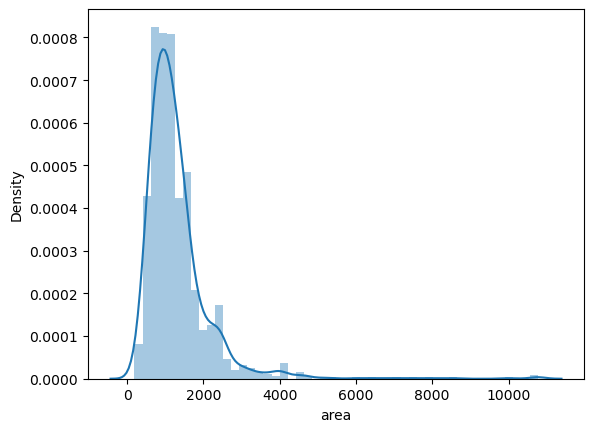

In [48]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

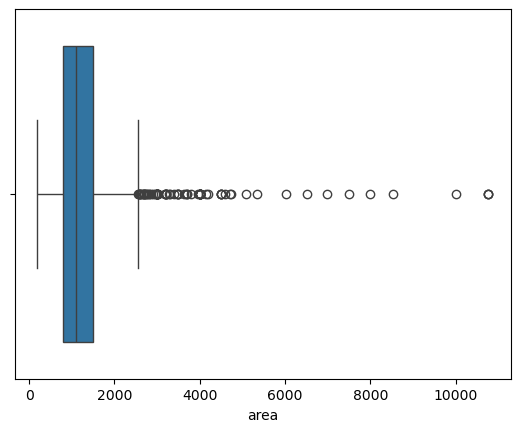

In [49]:
sns.boxplot(x=df['area'])

# genenuine outliers 

In [50]:
df.shape

(1571, 25)

In [51]:
df.head()

,society,colony,property_type,price_outer,price_per_sqft,Total Floors,Facing,Property Age,bedrooms,bathrooms,balconies,area,super_built_up_area,built_up_area,carpet_area,plot_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories
0,sage suncity,bhopal,House,105.0,3750,1.0,NaN,NaN,7,5,0,2800.00,NaN,2800.0,NaN,NaN,0,0,0,0,0,0,1,71,Green View Homes
1,danish hills view,kolar road,Flat,85.0,6508,2.0,North,New Property,3,3,1,1306.08,NaN,NaN,1306.0,NaN,0,0,0,1,0,1,1,35,Green View Homes
2,narmada prem kesar,katara hills,Flat,25.0,2173,3.0,West,New Property,2,2,3,1150.48,1150.0,NaN,850.0,NaN,0,0,0,0,0,0,1,15,Green View Homes
3,gurunanak pura independent house,aishbagh,House,65.0,5909,2.0,West,Old Property,8,5,1,1100.02,NaN,2400.0,2200.0,1100.0,0,0,0,1,0,0,0,18,Road Facing Homes
4,chuna bhatti,chuna bhatti,House,650.0,16250,3.0,NaN,New Property,6,6,2,4000.00,NaN,NaN,NaN,4000.0,1,1,1,1,0,0,2,10,Road Facing Homes


# Super built up area

C:\Users\Yogesh\AppData\Local\Temp\ipykernel_2784\4184943455.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['super_built_up_area'])


<Axes: xlabel='super_built_up_area', ylabel='Density'>

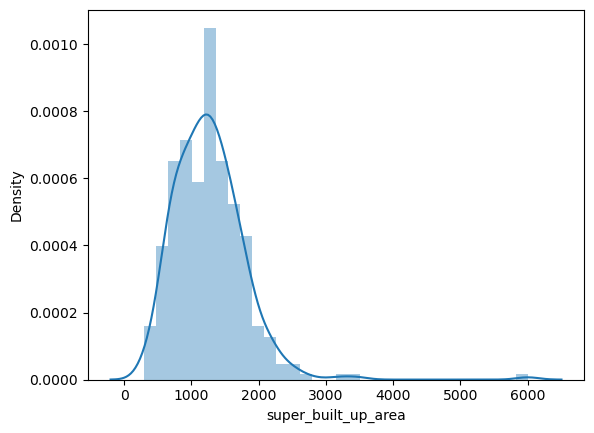

In [52]:
sns.distplot(df['super_built_up_area'])

<Axes: xlabel='super_built_up_area'>

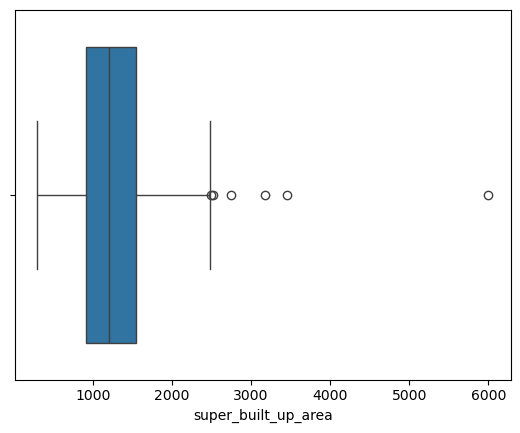

In [53]:
sns.boxplot(x=df['super_built_up_area'])

In [54]:
# built up area

C:\Users\Yogesh\AppData\Local\Temp\ipykernel_2784\3494228458.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['built_up_area'])


<Axes: xlabel='built_up_area', ylabel='Density'>

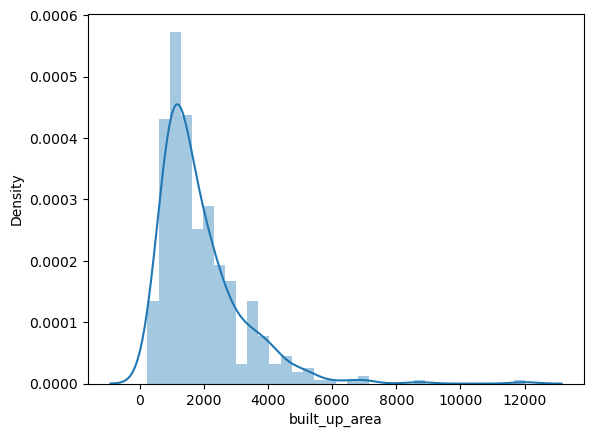

In [55]:
sns.distplot(df['built_up_area'])

<Axes: xlabel='built_up_area'>

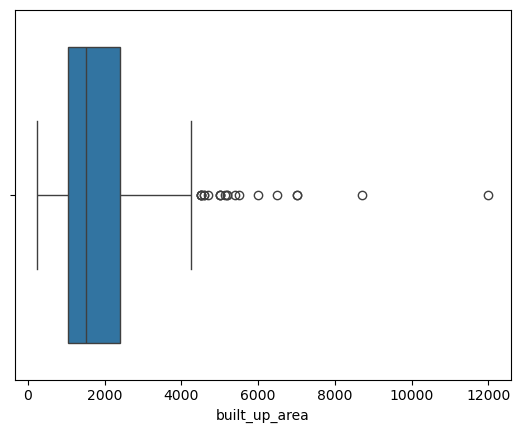

In [56]:
sns.boxplot(x=df['built_up_area'])

In [57]:
# Calculate the IQR for the 'price' column
Q1 = df['built_up_area'].quantile(0.25)
Q3 = df['built_up_area'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_area = df[(df['built_up_area'] < lower_bound) | (df['built_up_area'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers_area.shape[0]
outliers_area_stats = outliers_area['built_up_area'].describe()

num_outliers, outliers_area_stats

(21,
 count       21.000000
 mean      5738.285714
 std       1794.804784
 min       4500.000000
 25%       4600.000000
 50%       5125.000000
 75%       6000.000000
 max      12000.000000
 Name: built_up_area, dtype: float64)

# Carpet area

C:\Users\Yogesh\AppData\Local\Temp\ipykernel_2784\3905767603.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['carpet_area'])


<Axes: xlabel='carpet_area', ylabel='Density'>

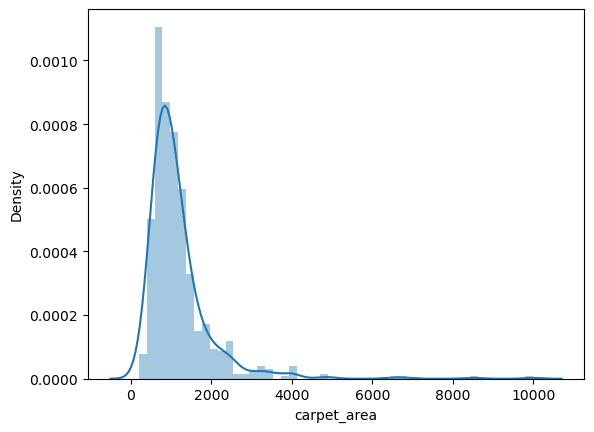

In [58]:
sns.distplot(df['carpet_area'])

<Axes: xlabel='carpet_area'>

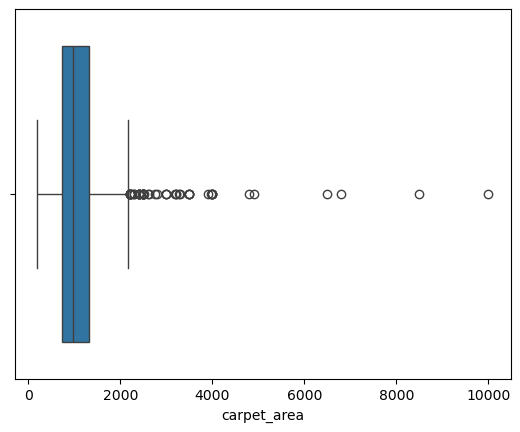

In [59]:
sns.boxplot(x=df['carpet_area'])

In [60]:
# Calculate the IQR for the 'price' column
Q1 = df['carpet_area'].quantile(0.25)
Q3 = df['carpet_area'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_area = df[(df['carpet_area'] < lower_bound) | (df['carpet_area'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers_area.shape[0]
outliers_area_stats = outliers_area['carpet_area'].describe()

num_outliers, outliers_area_stats

(53,
 count       53.000000
 mean      3291.075472
 std       1557.547664
 min       2200.000000
 25%       2400.000000
 50%       2611.000000
 75%       3500.000000
 max      10000.000000
 Name: carpet_area, dtype: float64)

In [61]:
outliers_area

,society,colony,property_type,price_outer,price_per_sqft,Total Floors,Facing,Property Age,bedrooms,bathrooms,balconies,area,super_built_up_area,built_up_area,carpet_area,plot_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories
3,gurunanak pura independent house,aishbagh,House,65.0,5909,2.0,West,Old Property,8,5,1,1100.02,NaN,2400.0,2200.0,1100.0,0,0,0,1,0,0,0,18,Road Facing Homes
10,chitrance sai vihar,outside bhopal,House,80.0,4210,2.0,North,New Property,3,3,2,1900.24,NaN,3000.0,2200.0,1900.0,0,0,0,0,0,0,0,17,Green View Homes
36,laharpur,bagmuliya,House,231.0,9240,2.0,South,Old Property,4,3,2,2500.00,NaN,3000.0,2500.0,2400.0,1,1,0,0,1,0,1,8,Green View Homes
50,sanjeev nagar,gandhinagar,House,175.0,3696,1.0,West,New Property,7,6,3,4734.85,NaN,4600.0,2400.0,NaN,0,0,0,0,0,0,1,7,Green View Homes
55,aakriti garden,central bhopal,House,175.0,7000,1.0,West,NaN,3,3,2,2500.00,NaN,NaN,2500.0,NaN,0,0,0,0,0,0,1,0,Road Facing Homes
56,new minal residency,bhopal,House,210.0,12580,1.0,West,Old Property,4,3,3,1669.32,NaN,2400.0,2250.0,1550.0,1,0,0,1,0,0,0,24,Green View Homes
91,noor mahal ashok colony,bhopal,House,250.0,9259,1.0,North-East,Old Property,4,3,2,2700.08,NaN,5400.0,4900.0,2700.0,1,1,0,0,0,0,0,27,Green View Homes
112,aks land mark sector a,bhopal,House,150.0,6250,1.0,NaN,New Property,4,4,0,2400.00,NaN,NaN,2400.0,NaN,0,0,0,0,0,0,1,0,Road Facing Homes
146,raj minal residency,ayodhya bypass,House,209.0,7013,3.0,East,Old Property,5,4,3,2980.18,NaN,3690.0,2980.0,1860.0,1,1,0,1,1,0,0,65,Road Facing Homes
184,luxe residences,bhopal,Flat,165.0,6600,5.0,North-East,NaN,4,4,2,2500.00,NaN,NaN,2500.0,NaN,0,0,0,1,1,1,1,26,Road Facing Homes


# plot area

C:\Users\Yogesh\AppData\Local\Temp\ipykernel_2784\1889983538.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['plot_area'])


<Axes: xlabel='plot_area', ylabel='Density'>

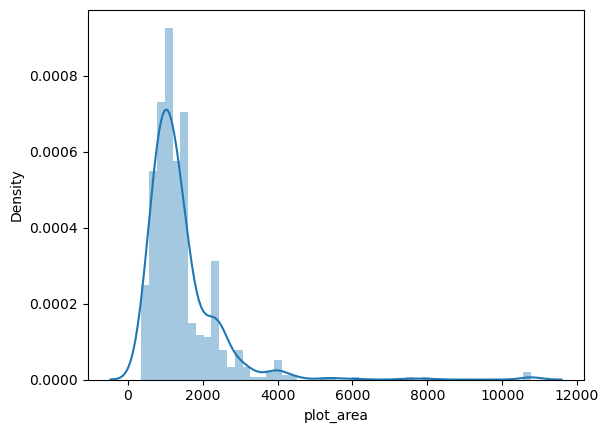

In [62]:
sns.distplot(df['plot_area'])

<Axes: ylabel='plot_area'>

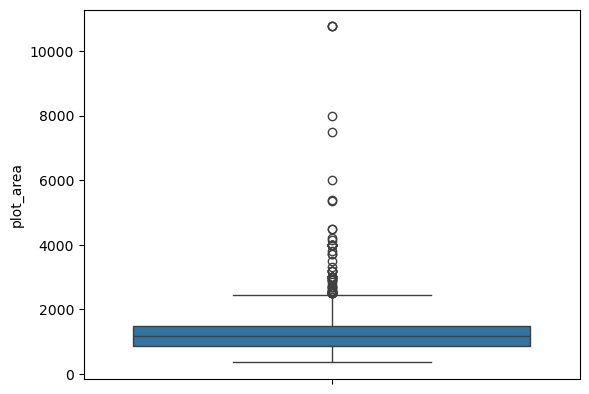

In [63]:
sns.boxplot(df['plot_area'])

In [64]:
df.head()

,society,colony,property_type,price_outer,price_per_sqft,Total Floors,Facing,Property Age,bedrooms,bathrooms,balconies,area,super_built_up_area,built_up_area,carpet_area,plot_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories
0,sage suncity,bhopal,House,105.0,3750,1.0,NaN,NaN,7,5,0,2800.00,NaN,2800.0,NaN,NaN,0,0,0,0,0,0,1,71,Green View Homes
1,danish hills view,kolar road,Flat,85.0,6508,2.0,North,New Property,3,3,1,1306.08,NaN,NaN,1306.0,NaN,0,0,0,1,0,1,1,35,Green View Homes
2,narmada prem kesar,katara hills,Flat,25.0,2173,3.0,West,New Property,2,2,3,1150.48,1150.0,NaN,850.0,NaN,0,0,0,0,0,0,1,15,Green View Homes
3,gurunanak pura independent house,aishbagh,House,65.0,5909,2.0,West,Old Property,8,5,1,1100.02,NaN,2400.0,2200.0,1100.0,0,0,0,1,0,0,0,18,Road Facing Homes
4,chuna bhatti,chuna bhatti,House,650.0,16250,3.0,NaN,New Property,6,6,2,4000.00,NaN,NaN,NaN,4000.0,1,1,1,1,0,0,2,10,Road Facing Homes


# area / bedroom ratio

In [65]:
df['area/bedrooms'] = df['area']/df['bedrooms']

In [66]:
df.head(1)

,society,colony,property_type,price_outer,price_per_sqft,Total Floors,Facing,Property Age,bedrooms,bathrooms,balconies,area,super_built_up_area,built_up_area,carpet_area,plot_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories,area/bedrooms
0,sage suncity,bhopal,House,105.0,3750,1.0,NaN,NaN,7,5,0,2800.0,NaN,2800.0,NaN,NaN,0,0,0,0,0,0,1,71,Green View Homes,400.0


In [67]:
df['area/bedrooms'].quantile([0.01,0.05,0.95,0.99])

0.01     129.375000
0.05     198.267500
0.95     721.313333
0.99    1079.059600
Name: area/bedrooms, dtype: float64

In [68]:
q5 = df['area/bedrooms'].quantile(0.05)

In [69]:
df[df['area/bedrooms']<=q5].sort_values(by='area/bedrooms',ascending=True)

,society,colony,property_type,price_outer,price_per_sqft,Total Floors,Facing,Property Age,bedrooms,bathrooms,balconies,area,super_built_up_area,built_up_area,carpet_area,plot_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories,area/bedrooms
886,aishbagh,aishbagh,House,65.0,10833,2.0,North,Old Property,10,5,3,600.02,NaN,NaN,NaN,600.0,0,0,0,0,0,0,1,8,Green View Homes,60.002000
352,aishbagh,aishbagh,House,55.0,12222,3.0,NaN,Moderate Property,5,4,1,450.01,NaN,NaN,NaN,450.0,0,0,0,0,0,0,1,20,Green View Homes,90.002000
847,city tower,peer gate area,House,120.0,19047,4.0,North,Old Property,7,4,2,630.02,NaN,2500.0,NaN,630.0,0,0,0,0,0,0,1,6,Road Facing Homes,90.002857
1152,risaldar colony chola naka,bhopal,House,65.0,7222,3.0,South,Old Property,10,4,3,900.03,NaN,NaN,NaN,900.0,0,0,0,0,1,0,1,0,Road Facing Homes,90.003000
1242,dwarka nagar,gandhinagar,House,70.0,9333,3.0,North,Moderate Property,8,4,2,750.03,NaN,NaN,NaN,750.0,0,0,0,0,0,0,1,16,Road Facing Homes,93.753750
89,people world,karond,House,27.0,6750,2.0,NaN,New Property,4,2,1,400.00,NaN,NaN,NaN,400.0,0,0,0,0,0,0,1,20,Road Facing Homes,100.000000
1194,jahangirabad,aishbagh,House,35.0,7000,3.0,NaN,Old Property,5,3,2,500.00,NaN,NaN,NaN,500.0,0,0,0,1,0,0,1,0,Road Facing Homes,100.000000
1482,afkar colony,bhopal,House,75.0,9375,2.0,East,Old Property,8,6,2,800.00,NaN,NaN,NaN,800.0,0,0,0,0,0,0,0,13,Road Facing Homes,100.000000
510,indra nagar,bhopal,House,40.0,3999,3.0,East,Old Property,10,4,2,1000.25,NaN,1800.0,NaN,1000.0,0,1,1,0,0,0,1,10,Road Facing Homes,100.025000
1556,bagh umrao dulha,bhopal,House,125.0,10416,3.0,NaN,Old Property,11,11,2,1200.08,NaN,NaN,NaN,1200.0,0,0,0,0,0,0,1,0,Road Facing Homes,109.098182


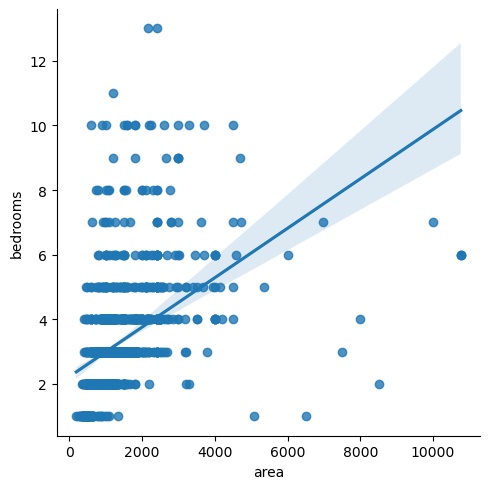

In [70]:
sns.lmplot(data = df,x='area',y='bedrooms')

In [71]:
df[df['area/bedrooms']<=q5]['bedrooms'].value_counts()


bedrooms
4     16
5     16
3     10
8      8
10     8
6      7
7      6
2      3
13     2
1      1
9      1
11     1
Name: count, dtype: int64

In [72]:
df = df[df['area/bedrooms']>=100]

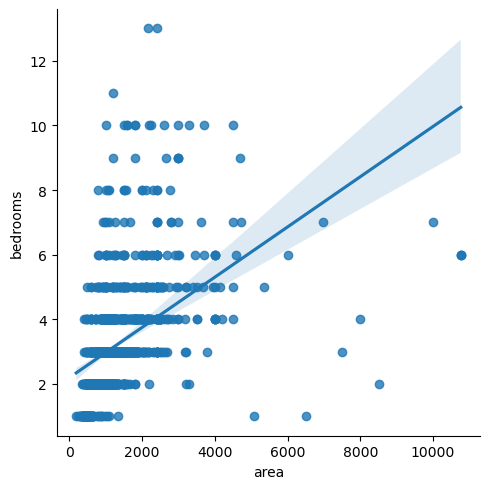

In [73]:
sns.lmplot(data = df,x='area',y='bedrooms')

In [74]:
df[(df['area/bedrooms']<q5)&(df['Total Floors']<2)]


,society,colony,property_type,price_outer,price_per_sqft,Total Floors,Facing,Property Age,bedrooms,bathrooms,balconies,area,super_built_up_area,built_up_area,carpet_area,plot_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories,area/bedrooms
77,kolar,kolar road,House,25.0,5555,1.0,West,New Property,3,3,0,450.05,NaN,NaN,NaN,450.0,0,0,0,0,0,0,1,10,Amenity Facing Homes,150.016667
102,geet mohini flats,ayodhya bypass,Flat,5.8,2989,0.0,South,Moderate Property,1,1,0,194.04,NaN,246.0,194.0,NaN,0,0,0,0,0,0,1,0,Road Facing Homes,194.040000
202,danish nagar d-1,bagmugaliya,Flat,300.0,13888,0.0,NaN,New Property,13,14,2,2160.14,6000.0,3600.0,2160.0,NaN,0,1,0,0,0,0,0,0,Road Facing Homes,166.164615
395,NaN,shahpura,Flat,21.0,3000,0.0,South-East,NaN,4,3,0,700.00,NaN,700.0,NaN,NaN,0,0,0,0,0,0,1,0,Road Facing Homes,175.000000
467,rajharsh colony kolar road,kolar road,House,40.0,6666,1.0,NaN,Old Property,4,4,1,600.06,NaN,NaN,NaN,600.0,0,0,1,0,0,0,1,3,Road Facing Homes,150.015000
792,shanti nagar berkhera pathni,habib ganj,House,10.0,2083,0.0,NaN,Old Property,3,1,0,480.08,NaN,NaN,NaN,480.0,0,0,0,0,0,0,1,0,Road Facing Homes,160.026667
1528,raunak apartment,bhopal,Flat,21.0,5399,1.0,NaN,Old Property,2,1,1,388.96,NaN,NaN,463.0,NaN,0,0,0,0,0,0,1,12,Green View Homes,194.480000
1534,ishaan vista,kolar road,House,40.0,6666,1.0,NaN,New Property,4,3,1,600.06,NaN,NaN,NaN,600.0,0,0,0,0,0,0,1,13,Amenity Facing Homes,150.015000


In [75]:
df[df['Total Floors']==0].shape


(67, 26)

In [76]:
ind  = df[df['Total Floors']==0]['Total Floors'].index
df.loc[ind,'Total Floors'] = 1

In [77]:
outliers_df = df[(df['area/bedrooms']<q5)&(df['bedrooms']>3)]
outliers_df

,society,colony,property_type,price_outer,price_per_sqft,Total Floors,Facing,Property Age,bedrooms,bathrooms,balconies,area,super_built_up_area,built_up_area,carpet_area,plot_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories,area/bedrooms
3,gurunanak pura independent house,aishbagh,House,65.0,5909,2.0,West,Old Property,8,5,1,1100.02,NaN,2400.0,2200.0,1100.0,0,0,0,1,0,0,0,18,Road Facing Homes,137.502500
15,mamta nagar,piplani,House,50.0,6153,3.0,North,Moderate Property,6,3,3,812.61,NaN,NaN,NaN,650.0,0,0,0,0,0,0,1,0,Road Facing Homes,135.435000
58,sanjeev nagar,gandhinagar,House,115.0,7666,2.0,West,Moderate Property,8,5,3,1500.13,NaN,NaN,NaN,1500.0,0,0,0,1,0,0,0,7,Green View Homes,187.516250
60,rajved colony,gehu kheda,House,31.0,5166,2.0,North,New Property,4,3,1,600.08,NaN,NaN,NaN,600.0,0,0,0,1,0,0,1,6,Road Facing Homes,150.020000
78,karod,karond,House,50.0,6666,3.0,NaN,New Property,5,7,3,750.08,NaN,NaN,NaN,750.0,0,0,0,0,0,0,1,0,Road Facing Homes,150.016000
89,people world,karond,House,27.0,6750,2.0,NaN,New Property,4,2,1,400.00,NaN,NaN,NaN,400.0,0,0,0,0,0,0,1,20,Road Facing Homes,100.000000
108,dilip nandgaon,bagmugaliya,House,65.0,6632,3.0,West,Moderate Property,7,3,2,980.10,NaN,2000.0,NaN,980.0,0,0,0,0,0,0,2,13,Green View Homes,140.014286
177,ibd raisina,patel nagar,House,128.0,7111,2.0,West,Moderate Property,10,6,3,1800.03,NaN,NaN,NaN,1800.0,0,1,0,0,0,0,1,11,Amenity Facing Homes,180.003000
181,mandideep,mandideep,House,82.0,5125,2.0,East,Moderate Property,10,7,2,1600.00,NaN,NaN,NaN,1600.0,0,1,0,0,0,0,1,8,Road Facing Homes,160.000000
202,danish nagar d-1,bagmugaliya,Flat,300.0,13888,1.0,NaN,New Property,13,14,2,2160.14,6000.0,3600.0,2160.0,NaN,0,1,0,0,0,0,0,0,Road Facing Homes,166.164615


In [78]:
outliers_df['bedrooms'] = round(outliers_df['bedrooms']/outliers_df['Total Floors'])


C:\Users\Yogesh\AppData\Local\Temp\ipykernel_2784\3212266321.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_df['bedrooms'] = round(outliers_df['bedrooms']/outliers_df['Total Floors'])


In [79]:
df.update(outliers_df)


In [80]:
df.to_csv('BPL_outliers_treated2.csv',index=False)